# Exploratory Data Analysis of YouTube Trending Videos

## Project Structure

- Title  
- Objective  
- Dataset Description  

- Step 1: Data Loading & Initial Inspection  
- Step 2: Data Cleaning & Feature Engineering  
- Step 3: Engagement Metric Creation  
- Step 4: Univariate Analysis  
- Step 5: Bivariate Analysis  
- Step 6: Viral Video Analysis  
- Step 7: Category-wise Analysis  
- Step 8: Title Length Analysis  
- Step 9: Temporal Analysis (Hour & Day)  
- Step 10: Distribution Analysis  
- Step 11: Insight Summary & Interpretation  
- Step 12: Actionable Recommendations  
- Step 13: Limitations & Future Scope


### Objective

The objective of this exploratory data analysis is to understand audience engagement patterns in YouTube trending videos. The analysis explores how factors such as views, video category, title length, and upload timing influence engagement rate, with the goal of identifying meaningful patterns and insights.


### Dataset Description

The dataset consists of metadata for YouTube trending videos, including information such as views, likes, comments, publish time, video category, and title text. An engagement rate metric is derived to represent the quality of audience interaction relative to reach.


### Step 1: Data Loading & Initial Inspection

In this step, we load the YouTube trending videos dataset and the category metadata.
The goal is to:
- Understand the structure and size of the dataset
- Preview the available columns and sample records
- Load category information to enable meaningful category-based analysis later

In [5]:
import pandas as pd
import json

# Paths
videos_path = r"D:\YouTube EDA project\archive\INvideos.csv"
category_path = r"D:\YouTube EDA project\archive\IN_category_id.json"

# Load CSV
videos_df = pd.read_csv(videos_path)
print("Videos data shape:", videos_df.shape)
print(videos_df.head())

# Load JSON
with open(category_path, 'r') as f:
    categories = json.load(f)

# Extract category details
cat_items = categories['items']
category_mapping = {int(item['id']): item['snippet']['title'] for item in cat_items}
print("\nCategory Mapping (Sample):", list(category_mapping.items())[:5])


Videos data shape: (37352, 16)
      video_id trending_date  \
0  kzwfHumJyYc      17.14.11   
1  zUZ1z7FwLc8      17.14.11   
2  10L1hZ9qa58      17.14.11   
3  N1vE8iiEg64      17.14.11   
4  kJzGH0PVQHQ      17.14.11   

                                               title    channel_title  \
0  Sharry Mann: Cute Munda ( Song Teaser) | Parmi...  Lokdhun Punjabi   
1  पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...          HJ NEWS   
2  Stylish Star Allu Arjun @ ChaySam Wedding Rece...             TFPC   
3                     Eruma Saani | Tamil vs English      Eruma Saani   
4  why Samantha became EMOTIONAL @ Samantha naga ...       Filmylooks   

   category_id              publish_time  \
0            1  2017-11-12T12:20:39.000Z   
1           25  2017-11-13T05:43:56.000Z   
2           24  2017-11-12T15:48:08.000Z   
3           23  2017-11-12T07:08:48.000Z   
4           24  2017-11-13T01:14:16.000Z   

                                                tags    views  likes  \


##### Mapping Category IDs to Category Names

To improve interpretability, category IDs in the dataset are mapped to their corresponding
category names using the category metadata. This allows all further analysis to be
performed using meaningful category labels instead of numeric codes.


In [7]:
# Add a readable category name column
videos_df['category_name'] = videos_df['category_id'].map(category_mapping)

# Check if it worked
print(videos_df[['category_id', 'category_name']].head(10))


   category_id     category_name
0            1  Film & Animation
1           25   News & Politics
2           24     Entertainment
3           23            Comedy
4           24     Entertainment
5           24     Entertainment
6           10             Music
7           10             Music
8           24     Entertainment
9           24     Entertainment


##### Observations from Step 1

- The dataset contains multiple features related to video performance such as views, likes, dislikes, comments, and publishing time.
- A preview of the data helps identify numeric and categorical variables for further analysis.
- Category IDs in the video dataset are mapped to human-readable category names using the JSON metadata.
- The newly created `category_name` column improves readability and enables category-wise trend analysis.
- This enrichment step ensures clearer insights in subsequent visualizations and summaries.


##### Dataset Structure and Quality Check

This section examines the overall structure of the dataset, including its size,
column names, data types, presence of missing values, and basic statistical
properties of numerical features. This helps identify potential data quality
issues before cleaning and feature engineering.


In [10]:
# Basic info about the dataset
print("Shape of dataset:", videos_df.shape)
print("\nColumn names:\n", videos_df.columns)
print("\nData types:\n", videos_df.dtypes)

# Check for missing values
print("\nMissing values in each column:\n", videos_df.isnull().sum())

# Summary statistics for numeric columns
print("\nStatistical Summary:\n", videos_df.describe())


Shape of dataset: (37352, 17)

Column names:
 Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name'],
      dtype='object')

Data types:
 video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
category_name             object
dtype: object

Missing values in each column:
 video_id               

##### Observations from Dataset Inspection

- The dataset contains a large number of records and multiple features describing video performance and metadata.
- Numerical columns such as views, likes, dislikes, and comment counts show wide value ranges, indicating possible skewness.
- Some columns contain missing values, which will need to be addressed during the data cleaning step.
- Data types confirm the presence of both numeric and categorical variables, as well as time-related fields.
- These observations guide the cleaning and feature engineering decisions in the next step.


### Step 2: Data Cleaning & Feature Engineering

This step prepares the dataset for analysis by handling missing values, 
correcting data types, and creating new features that will be used in 
later stages of the exploratory analysis.


In [13]:
# Check missing values again (for reference)
videos_df.isnull().sum()


video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               561
category_name             105
dtype: int64

##### Handling Missing Values

Missing values in key engagement-related columns can distort analysis.
Rows with missing views, likes, or comments are removed to ensure 
reliable engagement calculations.


In [15]:
# Drop rows with missing values in key performance columns
videos_df = videos_df.dropna(subset=['views', 'likes', 'comment_count'])


In [16]:
# Handle missing descriptions
videos_df['description'] = videos_df['description'].fillna('No description')

# Handle missing category names
videos_df['category_name'] = videos_df['category_name'].fillna('Unknown')


##### Datetime Conversion

Time-based analysis requires the publish timestamp to be in a proper 
datetime format.


In [18]:
videos_df['publish_time'] = pd.to_datetime(
    videos_df['publish_time'], errors='coerce'
)


##### Feature Engineering: Temporal Features

New features are extracted from the publish time to analyze engagement 
patterns by hour and day.


In [20]:
videos_df['publish_hour'] = videos_df['publish_time'].dt.hour
videos_df['publish_day'] = videos_df['publish_time'].dt.day_name()


In [21]:
print(videos_df[['publish_time', 'publish_hour', 'publish_day']].head())
print("Updated dataset shape:", videos_df.shape)


               publish_time  publish_hour publish_day
0 2017-11-12 12:20:39+00:00            12      Sunday
1 2017-11-13 05:43:56+00:00             5      Monday
2 2017-11-12 15:48:08+00:00            15      Sunday
3 2017-11-12 07:08:48+00:00             7      Sunday
4 2017-11-13 01:14:16+00:00             1      Monday
Updated dataset shape: (37352, 19)


##### Observations from Step 2

- Missing values in key engagement-related columns were removed.
- The publish timestamp was converted to datetime format.
- New temporal features (`publish_hour` and `publish_day`) were created.
- The dataset is now clean and structured for further exploratory analysis.


### Step 3: Engagement Metric Creation

##### Dataset Overview
After cleaning and preprocessing, we examine the structure of the dataset
to understand the available features and data types.


In [25]:
videos_df.shape

(37352, 19)

In [26]:
# Create engagement rate
videos_df['engagement_rate'] = (
    (videos_df['likes'] + videos_df['comment_count']) / videos_df['views']
)

# Remove zero-view videos to avoid invalid engagement
videos_df = videos_df[videos_df['views'] > 0]


##### Distribution of Video Views
This plot shows how video views are distributed across the dataset.


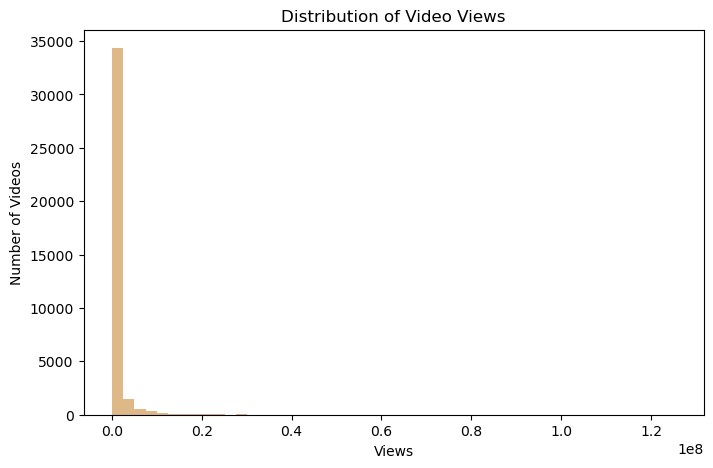

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(videos_df['views'], bins=50,color="#DEB887")
plt.xlabel('Views')
plt.ylabel('Number of Videos')
plt.title('Distribution of Video Views')
plt.show()


##### Distribution of Likes and Comments
We analyze how likes and comments are distributed among videos.


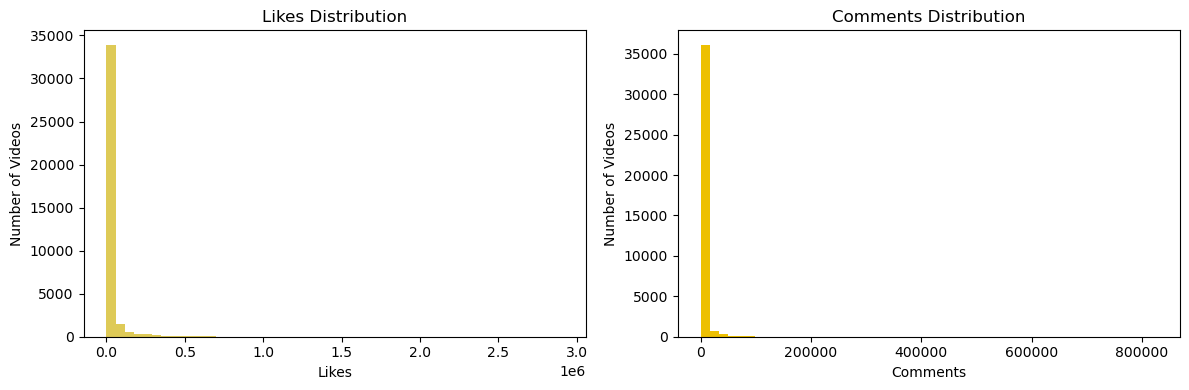

In [30]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(videos_df['likes'], bins=50,color="#DECA57")
plt.xlabel('Likes')
plt.ylabel('Number of Videos')
plt.title('Likes Distribution')

plt.subplot(1,2,2)
plt.hist(videos_df['comment_count'], bins=50,color="#EDC001")
plt.xlabel('Comments')
plt.ylabel('Number of Videos')
plt.title('Comments Distribution')

plt.tight_layout()
plt.show()


##### Average Views by Category
This analysis identifies which content categories receive
higher average views.


In [32]:
category_views = (
    videos_df.groupby('category_name')['views']
    .mean()
    .sort_values(ascending=False)
)

category_views.head(10)


category_name
Gaming                  4.162462e+06
Movies                  3.065001e+06
Music                   2.631116e+06
Film & Animation        2.320356e+06
Sports                  1.887755e+06
Pets & Animals          1.626581e+06
Entertainment           9.645997e+05
Howto & Style           8.725960e+05
Science & Technology    8.643316e+05
Comedy                  8.421324e+05
Name: views, dtype: float64

##### Correlation Analysis
We examine the relationship between views, likes, and comments
to understand engagement behavior.


In [34]:
videos_df[['views', 'likes', 'comment_count']].corr()


,views,likes,comment_count
views,1.000000,0.850096,0.674195
likes,0.850096,1.000000,0.780514
comment_count,0.674195,0.780514,1.000000


##### Observations & Insights

- Video views are highly skewed, with most videos receiving relatively low views
  and a small number achieving very high popularity.
- Likes and comments follow similar skewed patterns, indicating that engagement
  is concentrated on a limited subset of videos.
- Certain categories show higher average views than others, suggesting differences
  in audience interest across content types.
- Views and likes exhibit a strong positive relationship, meaning higher visibility
  generally leads to higher engagement.


### Step 4: Univariate Analysis

In this step, we analyze individual variables independently to understand their distributions, central tendencies, and variability. This helps identify skewness, outliers, and typical behavior of engagement-related metrics before exploring relationships between variables.


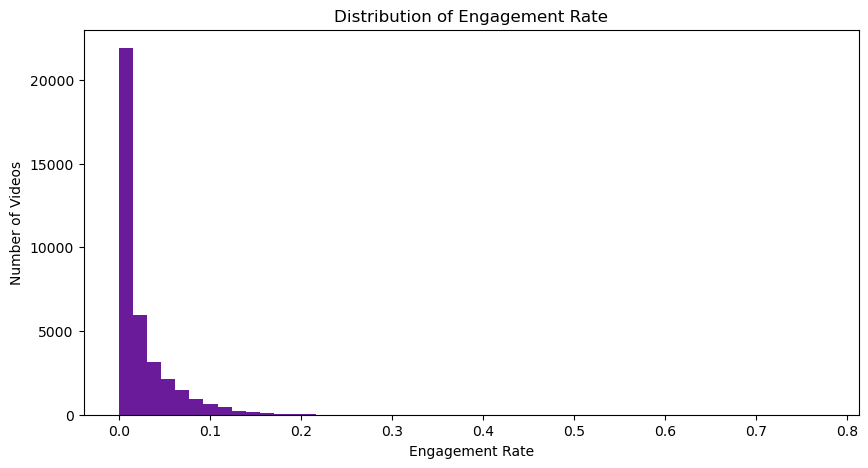

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(videos_df['engagement_rate'], bins=50,color="#6A1B9A")
plt.xlabel('Engagement Rate')
plt.ylabel('Number of Videos')
plt.title('Distribution of Engagement Rate')
plt.show()


##### Engagement Rate Distribution

The histogram shows how engagement rates are distributed across videos. This helps identify whether engagement is evenly spread or concentrated among a small subset of videos.

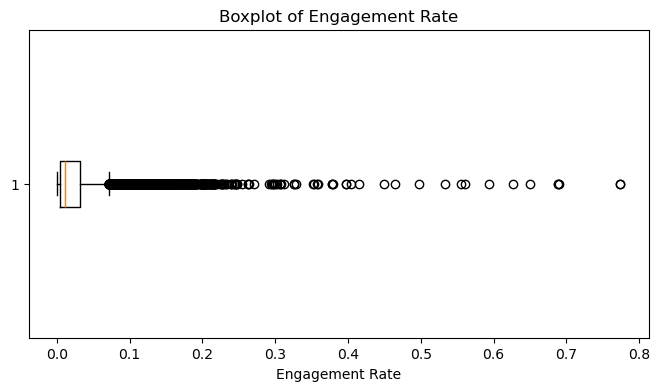

In [39]:
plt.figure(figsize=(8,4))
plt.boxplot(videos_df['engagement_rate'], vert=False)
plt.xlabel('Engagement Rate')
plt.title('Boxplot of Engagement Rate')
plt.show()


The boxplot provides a clear view of the median engagement rate, spread of the middle 50% of values, and the presence of outliers. Outliers represent videos with unusually high engagement relative to typical content.


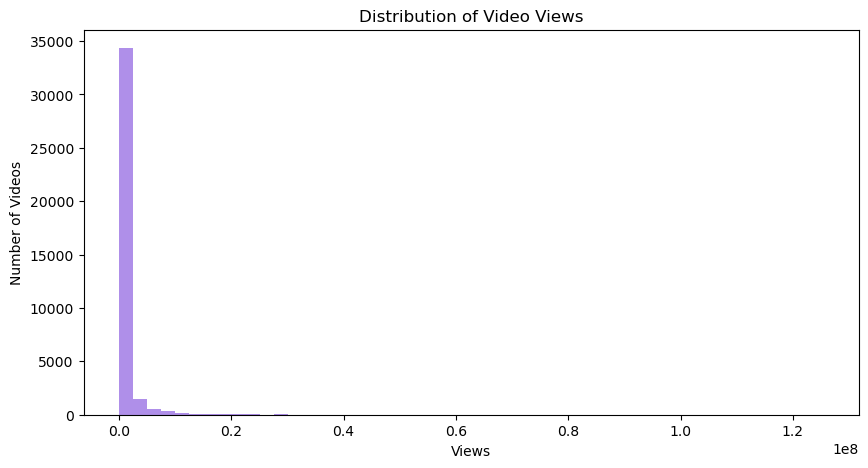

In [41]:
plt.figure(figsize=(10,5))
plt.hist(videos_df['views'], bins=50,color="#AF8FE9")
plt.xlabel('Views')
plt.ylabel('Number of Videos')
plt.title('Distribution of Video Views')
plt.show()


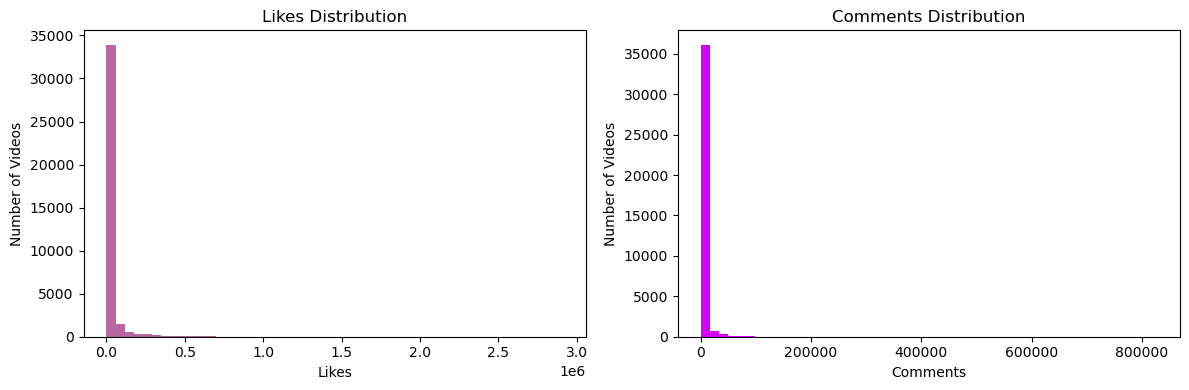

In [42]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(videos_df['likes'], bins=50,color="#B768A2")
plt.xlabel('Likes')
plt.ylabel('Number of Videos')
plt.title('Likes Distribution')

plt.subplot(1,2,2)
plt.hist(videos_df['comment_count'], bins=50,color="#D500F9")
plt.xlabel('Comments')
plt.ylabel('Number of Videos')
plt.title('Comments Distribution')

plt.tight_layout()
plt.show()


Views, likes, and comment counts all exhibit highly right-skewed distributions. Most videos receive relatively low values, while a small number of videos achieve extremely high engagement. This confirms the presence of viral outliers.


##### Observations from Univariate Analysis

- Engagement rate is highly skewed, with most videos showing low engagement and a small number of videos achieving exceptionally high engagement.
- Boxplots reveal a low median engagement rate and a large number of outliers, indicating that viral videos are not representative of typical performance.
- Views, likes, and comment counts all follow long-tailed distributions, confirming that YouTube engagement is dominated by a minority of highly successful videos.
- Comment counts show the strongest skew, suggesting that active audience participation is concentrated among a small subset of content.

These findings justify the use of median-based metrics and motivate separate analysis of viral videos in later steps.


### Step 5: Bivariate Analysis

Bivariate analysis examines the relationship between two variables at a time. In this step, we analyze how different engagement metrics 
interact with each other to understand patterns, correlations, and dependencies in YouTube video performance.
This analysis helps answer questions such as:
- Do videos with more views receive more likes?
- Is there a relationship between views and comments?
- How does engagement rate vary with views?


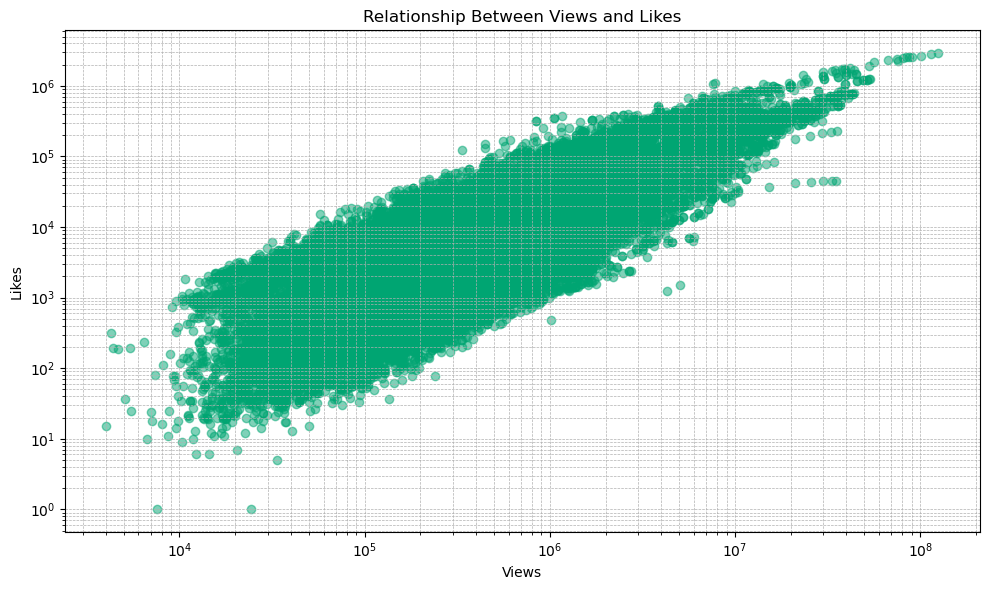

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(videos_df['views'], videos_df['likes'], alpha=0.5,color="#00A572")

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Views')
plt.ylabel('Likes')
plt.title('Relationship Between Views and Likes')

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


This scatter plot visualizes the relationship between video views and likes.
Both axes are plotted on a logarithmic scale to handle the wide range of value 
and to make patterns me e visib . Each point represents a video.


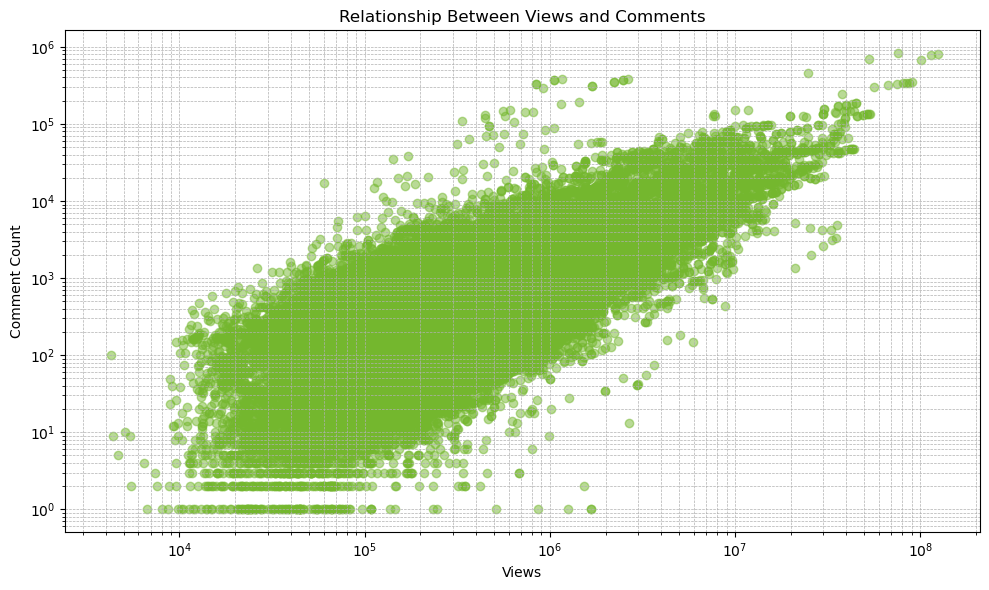

In [49]:
plt.figure(figsize=(10,6))
plt.scatter(videos_df['views'], videos_df['comment_count'], alpha=0.5,color="#74B72E")

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Views')
plt.ylabel('Comment Count')
plt.title('Relationship Between Views and Comments')

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


This plot shows how comment activity changes as view counts increase.
Logarithmic scaling helps highlight patterns across both low- and high-performing videos.


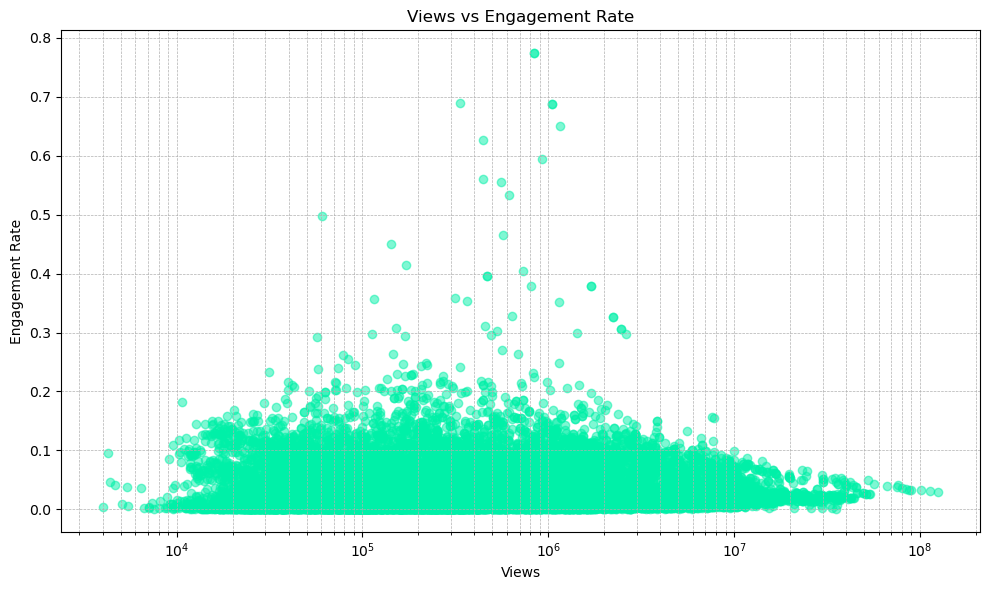

In [51]:
plt.figure(figsize=(10,6))
plt.scatter(videos_df['views'], videos_df['engagement_rate'], alpha=0.5,color="#00F0A8")

plt.xscale('log')

plt.xlabel('Views')
plt.ylabel('Engagement Rate')
plt.title('Views vs Engagement Rate')

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


This scatter plot explores how engagement rate varies with the number of views.
It helps determine whether high-view videos necessarily have higher engagement.


In [53]:
videos_df[['views', 'likes', 'comment_count', 'engagement_rate']].corr()

,views,likes,comment_count,engagement_rate
views,1.000000,0.850096,0.674195,0.033875
likes,0.850096,1.000000,0.780514,0.246275
comment_count,0.674195,0.780514,1.000000,0.303449
engagement_rate,0.033875,0.246275,0.303449,1.000000


The correlation matrix quantifies the strength and direction of relationships
between engagement metrics.

Correlation values range from -1 to +1:
- Values close to +1 indicate strong positive correlation
- Values close to 0 indicate weak or no correlation
- Values close to -1 indicate strong negative correlation


##### Observations from Bivariate Analysis

- Views and likes show a strong positive relationship, indicating that videos
  with higher visibility generally receive more likes.
- Views and comment counts are positively correlated, but the relationship is
  weaker compared to likes, suggesting that commenting behavior is more selective.
- Engagement rate tends to decrease as views increase, implying that viral videos
  often attract passive viewers rather than proportionally higher interaction.
- The correlation matrix confirms that views, likes, and comments are strongly
  related, while engagement rate behaves differently from raw engagement counts.

These insights highlight the difference between popularity and true audience engagement
and set the foundation for outlier and viral video analysis in the next step.


### Step 6: Outlier & Viral Video Analysis

Using the IQR method, videos with exceptionally high engagement rates were
identified as outliers (viral videos). These videos represent a small fraction
of total content but contribute disproportionately to overall engagement.

Analysis shows that viral videos are not always the most viewed, indicating that
engagement quality (likes and comments) is more important than sheer reach.
Certain categories appear more frequently among viral videos, suggesting that
content type plays a key role in audience inteVirality is defined statistically using the Interquartile Range (IQR) method on engagement rate.raction.


##### Defining a Viral Engagement Threshold (IQR Method)

The Interquartile Range (IQR) method is used to detect statistically extreme values.Any video whose engagement rate lies far above the
typical range is classified as viral.
The viral threshold is calculated as:
Viral Threshold = Q3 + 1.5 × IQR

Where:
- Q1 is the 25th percentile
- Q3 is the 75th percentile
- IQR represents the spread of the middle 50% of data

In [58]:
# Calculate quartiles
Q1 = videos_df['engagement_rate'].quantile(0.25)
Q3 = videos_df['engagement_rate'].quantile(0.75)
IQR = Q3 - Q1

# Define viral threshold
viral_threshold = Q3 + 1.5 * IQR

viral_threshold


0.07193799397144918

##### Extracting Viral Videos

Using the calculated viral threshold, we now filter the dataset to extract videos
whose engagement rate exceeds this limit.

These videos are considered statistically viral due to their unusually high audience interaction.

In [60]:
viral_videos = videos_df[videos_df['engagement_rate'] > viral_threshold]
viral_videos

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name,publish_hour,publish_day,engagement_rate
16,ep3SLMuRbvg,17.14.11,TYPES OF STUDENTS- | Elvish Yadav |,Elvish yadav,23,2017-11-13 11:26:02+00:00,"TYPES OF STUDENTS ELVISH YADAV|""elvish yadav""|...",344545,25717,417,2870,https://i.ytimg.com/vi/ep3SLMuRbvg/default.jpg,False,False,False,This video shows different types of students p...,Comedy,11,Monday,0.082970
18,CLl1RbxDRAs,17.14.11,Meri Setting Karwado Prank - Bakchodi ki Hadd ...,TroubleSeekerTeam,23,2017-11-12 13:16:38+00:00,"Prank Call|""Funny Reactions""|""Pranks In India ...",209599,14070,448,1105,https://i.ytimg.com/vi/CLl1RbxDRAs/default.jpg,False,False,False,Subscribe karo aur Bell Icon pe click karo \nI...,Comedy,13,Sunday,0.072400
53,y6YY8-k9Cwg,17.14.11,7 DAILY HABITS OF SELF MADE MILLIONAIRES (HINDI),SeeKen,27,2017-11-12 06:46:34+00:00,"rich|""millionaire""|""habits""|""hindi""|""urdu""|""7 ...",103239,7191,91,746,https://i.ytimg.com/vi/y6YY8-k9Cwg/default.jpg,False,False,False,21 SECRETS OF SELF MADE MILLIONAIRES BY BRIAN ...,Education,6,Sunday,0.076880
61,ozZ8HpIBsGw,17.14.11,Mersal - A minute of Aalaporaan Thamizhan | Vi...,Sony Music India,10,2017-11-10 11:30:01+00:00,"Sony Music India|""Sony Music""|""Latest Hits""|""k...",1449239,120289,3108,3296,https://i.ytimg.com/vi/ozZ8HpIBsGw/default.jpg,False,False,False,‘Aalaporaan Thamizhan’ is a larger than life c...,Music,11,Friday,0.085276
86,5zHIyadCwwE,17.14.11,"Tech Talks #346 - Moto X4, BharatNet II, iPhon...",Technical Guruji,28,2017-11-13 16:58:20+00:00,"Moto X4|""Oneplus 5T""|""Jio Latest""|""technical g...",153384,29321,750,1787,https://i.ytimg.com/vi/5zHIyadCwwE/default.jpg,False,False,False,TG Deals@ https://tg.deals/\nNew Channel: http...,Science & Technology,16,Monday,0.202811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37319,1-0mS2ZBrQk,18.14.06,What If PubG Was Made In India ?,Angry Prash,23,2018-06-11 08:37:21+00:00,"pubg|""PlayerUnknown's Battlegrounds""|""pubg mob...",1214423,85601,4677,7628,https://i.ytimg.com/vi/1-0mS2ZBrQk/default.jpg,False,False,False,This funny video is about what if players unkn...,Comedy,8,Monday,0.076768
37330,K10YIAokjvE,18.14.06,Funny Ramzan Scenes Part - 2 | Hyderabadi Come...,Warangal Diaries,23,2018-06-13 10:16:21+00:00,"warangal diaries|""latest""|""funny""|""comedy""|""Ba...",132055,11170,393,2107,https://i.ytimg.com/vi/K10YIAokjvE/default.jpg,False,False,False,(Earphone Use Is Recommended)!!Funny Ramzan Sc...,Comedy,10,Wednesday,0.100541
37333,AuSew0AGngE,18.14.06,Sinthir Sindoor Movie Funny Review| E Kemon Ci...,The Bong Guy,23,2018-06-12 12:35:31+00:00,"e kemon cinema|""e kemon gaan""|""the bong guy""|""...",296798,38333,864,6230,https://i.ytimg.com/vi/AuSew0AGngE/default.jpg,False,False,False,Did you like the video? Then give me a big thu...,Comedy,12,Tuesday,0.150146
37336,pnD-jQSlpyA,18.14.06,RISHTA LEKE AATA HU - Bakchodi ki Hadd - Ep 33...,TroubleSeekerTeam,23,2018-06-13 11:00:59+00:00,"tst|""tst rahul""|""tst rahul prince""|""Bakchodi k...",235634,25737,439,1713,https://i.ytimg.com/vi/pnD-jQSlpyA/default.jpg,False,False,False,Get the Happn App - http://gethap.pn/jQrR3YSub...,Comedy,11,Wednesday,0.116494


##### Comparing Viral and Non-Viral Content Volume

To understand how rare viral videos are, we compare:
- Total number of videos
- Number of viral videos
- Number of non-viral videos

This provides context on how much influence viral videos may have on overall engagement trends.


In [62]:
viral_videos = videos_df[videos_df['engagement_rate'] > viral_threshold]
normal_videos = videos_df[videos_df['engagement_rate'] <= viral_threshold]

print(f"Total videos: {len(videos_df)}")
print(f"Viral videos: {len(viral_videos)}")
print(f"Non-viral videos: {len(normal_videos)}")


Total videos: 37352
Viral videos: 3212
Non-viral videos: 34140


##### Inspecting Top Viral Videos

We now examine the most engaging viral videos to better understand:
- Their engagement intensity
- Their view counts
- Their content categories

This helps assess whether viral engagement is driven primarily by reach or by audience interaction.


In [64]:
viral_videos_sorted = viral_videos.sort_values(
    by='engagement_rate', ascending=False
)

viral_videos_sorted[
    ['title', 'category_name', 'views', 'likes', 'comment_count', 'engagement_rate']
].head(10)


,title,category_name,views,likes,comment_count,engagement_rate
35169,OnePlus 6 Top Features and GIVEAWAY 🔥- OnePlus...,Science & Technology,840727,321088,329872,0.774282
35031,OnePlus 6 Top Features and GIVEAWAY 🔥- OnePlus...,Science & Technology,840727,321088,329872,0.774282
16612,Oneplus 5T Lava Red Unboxing and Giveaway 🔥🔥🔥 ...,Science & Technology,335058,122284,108681,0.689328
35360,OnePlus 6 Top Features and GIVEAWAY 🔥- OnePlus...,Science & Technology,1049339,355742,367019,0.688777
35229,OnePlus 6 Top Features and GIVEAWAY 🔥- OnePlus...,Science & Technology,1049339,355742,367019,0.688777
35445,OnePlus 6 Top Features and GIVEAWAY 🔥- OnePlus...,Science & Technology,1158291,370533,382685,0.650284
6127,OnePlus 5T Star Wars Limited Edition Unboxing ...,Science & Technology,446587,148132,131842,0.626919
26057,Samsung Galaxy S9 Top Features and Tips Tricks...,Science & Technology,921731,252602,295139,0.594253
16850,Oneplus 5T Lava Red Unboxing and Giveaway 🔥🔥🔥 ...,Science & Technology,446879,131887,118594,0.560512
6318,OnePlus 5T Star Wars Limited Edition Unboxing ...,Science & Technology,559686,165108,145754,0.555422


##### Category Distribution Among Viral Videos

Next, we analyze which content categories appear most frequently among viral videos.
This helps identify whether certain categories are more prone to generating extreme engagement.


In [66]:
viral_videos['category_name'].value_counts().head(10)


category_name
Comedy                  1152
Entertainment            897
Education                422
Science & Technology     282
People & Blogs           170
Music                    158
Film & Animation          54
News & Politics           30
Howto & Style             19
Gaming                    13
Name: count, dtype: int64

##### Relationship Between Views and Engagement in Viral Videos

To evaluate whether high engagement among viral videos is simply a result of high view counts,
we calculate the correlation between views and engagement rate within the viral subset.


In [68]:
viral_videos[['views', 'engagement_rate']].corr()


,views,engagement_rate
views,1.000000,-0.094237
engagement_rate,-0.094237,1.000000


##### Observations from Outlier & Viral Video Analysis

- Viral videos constitute a very small percentage of the total dataset, confirming that extreme engagement is rare on YouTube.
- High engagement rate does not necessarily correspond to extremely high view counts, indicating that virality is driven by audience interaction rather than reach alone.
- Certain content categories appear more frequently among viral videos, suggesting that content type plays a significant role in encouraging likes and commename.
- These findings justify treating viral videos separately from typical content and motivate focused analysis on engagement-driven suc- - ess.

Correlation analysis between views and engagement rate among viral videos shows a weak negative relationship (r = −0.10). This indicates that higher view counts do not translate into higher engagement quality, reinforcing the observation that virality is driven more by audience interaction than reach.

### Step 7:Category-wise Analysis

In this step, we analyze how engagement varies across different content categories.
The objective is to understand whether certain categories consistently achieve highe 
audience interaction and how engagement behavior differs within categories


This analysis complements the viral video study by showing whether high engageent
is driven by category-specific appeal rather than isolated viral events.

##### Average Engagement Rate by Category

We begin by calculating the average engagement rate for each video category.
This helps identify categories that typically generate stronger audience interaction
per view, regardless of total view count.

In [73]:
#Average engagement rate by category
category_engagement = (
    videos_df
    .groupby('category_name')['engagement_rate']
    .mean()
    .sort_values(ascending=False)
)

category_engagement.head(10)


category_name
Science & Technology    0.105682
Pets & Animals          0.060134
Education               0.059991
Comedy                  0.059166
Gaming                  0.040553
Unknown                 0.034587
Music                   0.027816
Autos & Vehicles        0.025097
Film & Animation        0.021818
Movies                  0.019227
Name: engagement_rate, dtype: float64

##### Top Categories by Average Engagement

The bar chart below visualizes the top categories based on their average engagement rate.
This allows for easy comparison of which content types tend to perform better in terms
of likes and comments relative to views.


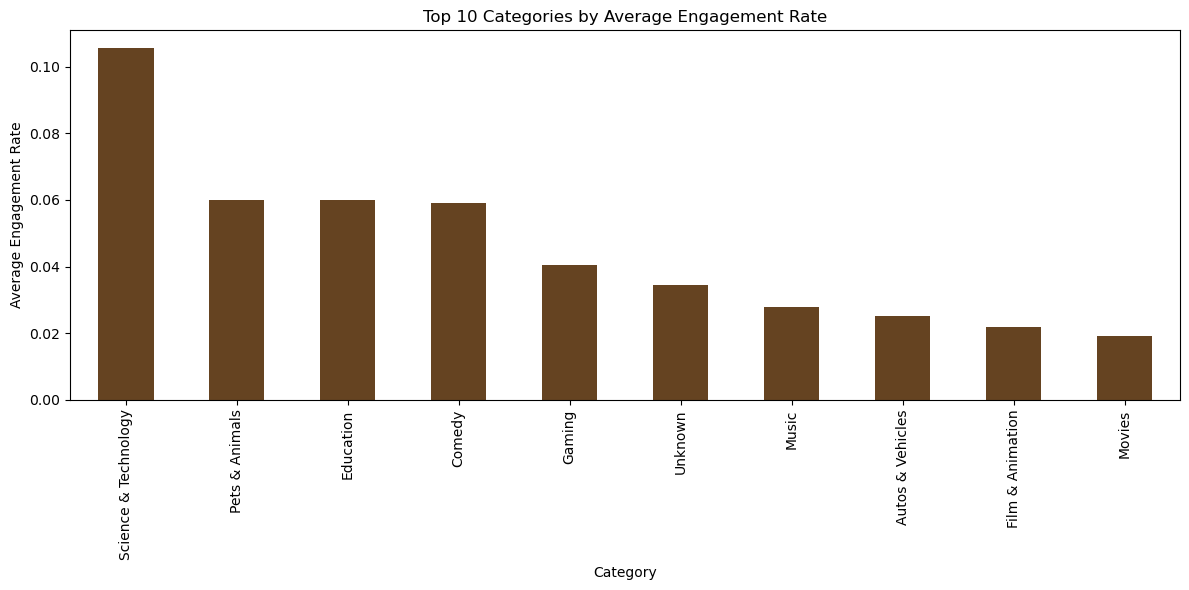

In [75]:
#Visualize category engagement
plt.figure(figsize=(12,6))
category_engagement.head(10).plot(kind='bar',color="#654321")

plt.title('Top 10 Categories by Average Engagement Rate')
plt.xlabel('Category')
plt.ylabel('Average Engagement Rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


##### Engagement Distribution Within Categories

While average engagement provides a summary measure, it does not reveal variability.
To understand consistency and the presence of extreme engagement values, we examine
the distribution of engagement rates within each category using boxplots.

This helps distinguish:
- Categories with consistently strong engagement
- Categories with occasional extreme (viral) engagement


<Figure size 1200x600 with 0 Axes>

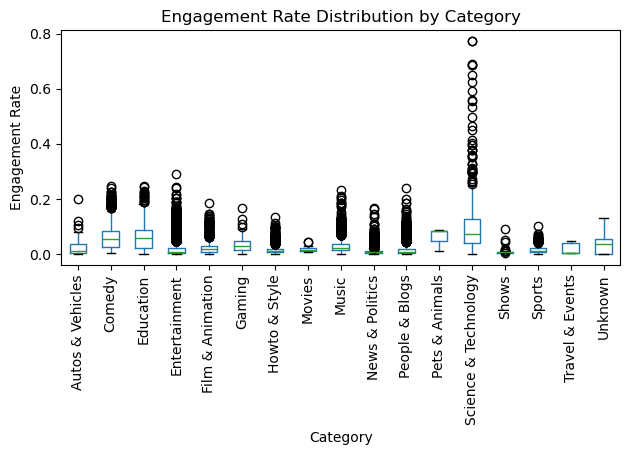

In [77]:
plt.figure(figsize=(12,6))
videos_df.boxplot(
    column='engagement_rate',
    by='category_name',
    grid=False
)

plt.xticks(rotation=90)
plt.title('Engagement Rate Distribution by Category')
plt.suptitle('')
plt.xlabel('Category')
plt.ylabel('Engagement Rate')
plt.tight_layout()
plt.show()


##### Observations from Category-wise Analysis

- Engagement behavior varies significantly across categories, indicating that content
  type plays a major role in audience interaction.
- Some categories show higher average engagement rates, suggesting they consistently
  encourage likes and comments rather than relying on rare viral spikes.
- Boxplots reveal that certain categories have wide engagement distributions with
  extreme outliers, explaining their presence among viral videos despite lower
  typical performance.
- Other categories exhibit tighter engagement distributions, indicating more stable
  and predictable audience response.
- These findings suggest that virality is not evenly distributed across content types
  and that category-specific strategies may be more effective than a uniform approach.
al.


### Step 8: Title Analysis (Text-based Patterns)

In this step, we examine whether video title length has any relationship with
audience engagement. Titles play a critical role in attracting clicks, but it
is unclear whether longer or shorter titles lead to higher engagement quality.

This analysis explores both overall trends and engagement behavior across
different title length ranges.

##### Title Length Feature Creation

We first compute the length of each video title by counting the number of
characters. This derived feature will be used to study how engagement varies
with title length.


In [82]:
# Length of each video title (number of characters)
videos_df['title_length'] = videos_df['title'].str.len()


##### Relationship Between Title Length and Engagement Rate

A scatter plot is used to visualize the relationship between title length and
engagement rate. This helps identify any visible trends, clusters, or outliers
and assess whether title length alone influences engagement.


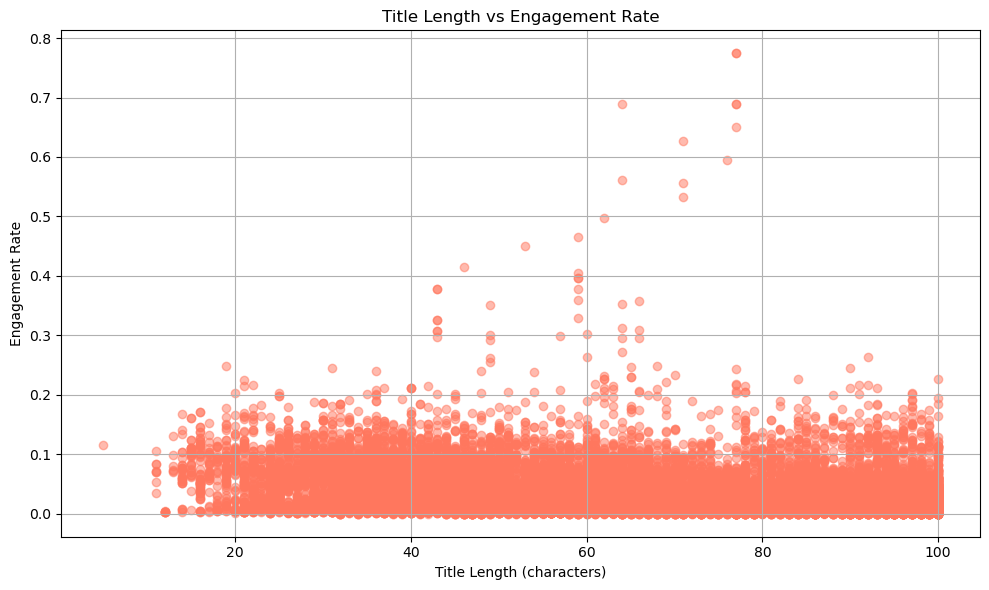

In [84]:
plt.figure(figsize=(10,6))
plt.scatter(
    videos_df['title_length'],
    videos_df['engagement_rate'],
    alpha=0.5,color="#FF775E"
)

plt.xlabel('Title Length (characters)')
plt.ylabel('Engagement Rate')
plt.title('Title Length vs Engagement Rate')
plt.grid(True)
plt.tight_layout()
plt.show()


A scatterplot of title length versus engagement rate shows no strong linear relationship, indicating that title length alone does not predict engagement. Most videos cluster at low engagement levels regardless of title length, while rare high-engagement outliers appear more frequently at moderate title lengths. To better summarize this pattern and compare typical engagement behavior across ranges, title lengths were grouped and analyzed using boxplots.

##### Engagement Patterns Across Title Length Groups

Since the scatter plot does not show a strong linear relationship, title lengths
are grouped into meaningful ranges. Boxplots are then used to compare the typical
engagement behavior and variability across these groups.


<Figure size 1000x600 with 0 Axes>

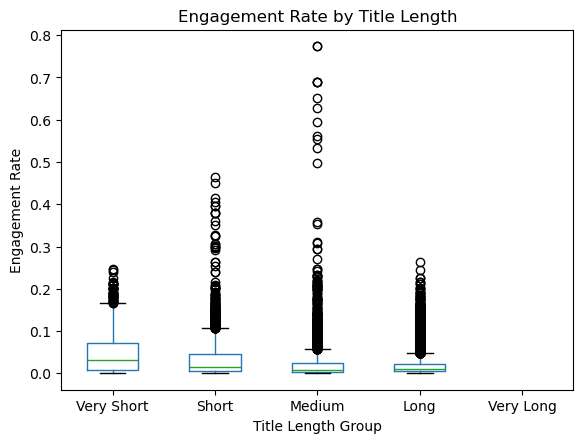

In [87]:
# Create title length groups
videos_df['title_length_group'] = pd.cut(
    videos_df['title_length'],
    bins=[0, 40, 60, 80, 120, 300],
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
)

# Boxplot
plt.figure(figsize=(10,6))
videos_df.boxplot(
    column='engagement_rate',
    by='title_length_group',
    grid=False
)

plt.xlabel('Title Length Group')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate by Title Length')
plt.suptitle('')
plt.show()


Boxplot analysis of engagement rate by title length shows that very short titles achieve the highest typical engagement but also display greater variability among the middle 50% of videos. Long titles demonstrate the most consistent engagement behavior, with a narrow interquartile range but lower median performance. Medium-length titles exhibit numerous extreme outliers, indicating occasional viral success despite lower typical engagement levels. Overall, shorter titles tend to perform better on average, while medium titles enable rare high-impact outcomes.

##### Observations from Title Length Analysis

- Title length alone does not strongly predict engagement rate, as shown by the
  lack of a clear trend in the scatter plot.
- Very short titles tend to achieve higher median engagement but also show greater
  variability, indicating both strong performance and inconsistency.
- Long titles exhibit more stable engagement behavior, with a narrow interquartile
  range but lower typical engagement levels.
- Medium-length titles produce several extreme outliers, suggesting that while
  they do not perform best on average, they occasionally lead to viral success.
- Overall, concise titles tend to perform better on average, while moderate-length
  titles allow for rare high-impact engagement.


### Step 9:Temporal Analysis (Hour & Day)

In this step, we analyze how video engagement varies across time-based factors,
specifically the hour of upload and the day of the week. Temporal analysis helps
identify audience activity patterns and assess whether publishing time is
associated with higher or lower engagement levels.

##### Time Feature Extraction

The video publish time is converted into a datetime format to extract useful
temporal features. Upload hour and day of the week are derived to enable
time-based grouping and analysis.


In [93]:
# Convert publish_time to datetime
videos_df['publish_time'] = pd.to_datetime(videos_df['publish_time'])

# Extract time features
videos_df['publish_hour'] = videos_df['publish_time'].dt.hour
videos_df['publish_day'] = videos_df['publish_time'].dt.day_name()


##### Engagement Patterns by Upload Hour

Median engagement rate is calculated for each upload hour to understand how
typical engagement varies throughout the day. Median values are used instead of
means to reduce the influence of extreme viral outliers.


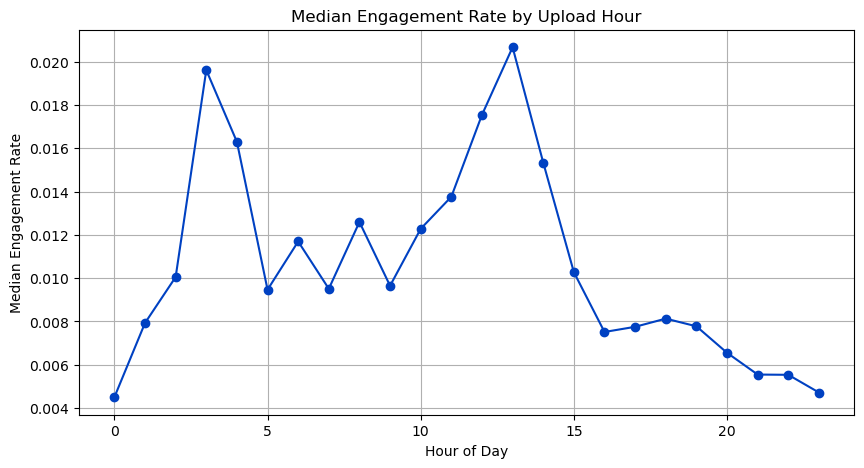

In [95]:
hourly_engagement = (
    videos_df
    .groupby('publish_hour')['engagement_rate']
    .median()
)

plt.figure(figsize=(10,5))
hourly_engagement.plot(kind='line', marker='o',color="#0041C2")
plt.xlabel('Hour of Day')
plt.ylabel('Median Engagement Rate')
plt.title('Median Engagement Rate by Upload Hour')
plt.grid(True)
plt.show()


Median engagement rate varies across upload hours, with noticeable peaks during early morning and midday. The highest typical engagement occurs around noon, while late evening uploads show lower engagement. The smooth trend across hours suggests gradual changes in audience activity rather than abrupt behavioral shifts.

##### Engagement Patterns by Upload Day

To analyze weekly engagement trends, median engagement rates are computed for
each day of the week. Days are ordered chronologically to improve interpretability
of the visualization.


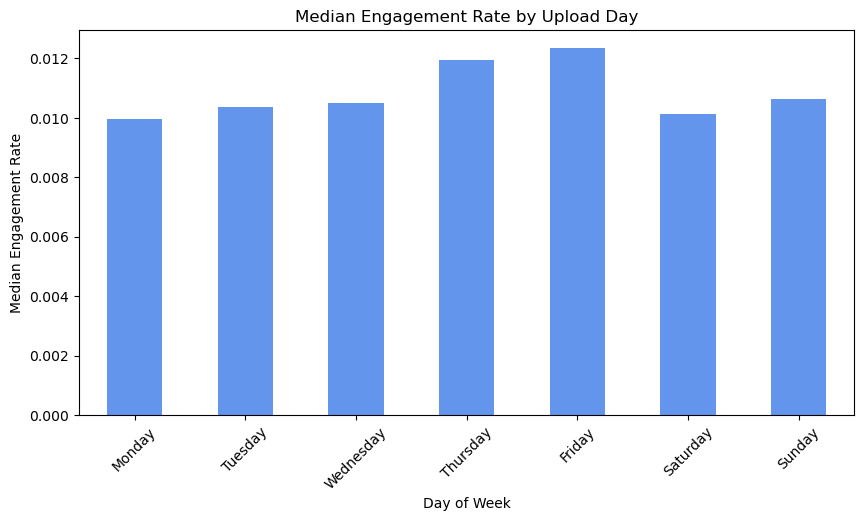

In [98]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_engagement = (
    videos_df
    .groupby('publish_day')['engagement_rate']
    .median()
    .reindex(day_order)
)

plt.figure(figsize=(10,5))
daily_engagement.plot(kind='bar',color="#6495ED")
plt.xlabel('Day of Week')
plt.ylabel('Median Engagement Rate')
plt.title('Median Engagement Rate by Upload Day')
plt.xticks(rotation=45)
plt.show()


The bar chart shows that median engagement varies across upload days, with Thursday and Friday exhibiting the highest typical engagement and Saturday the lowest. Weekdays generally outperform weekends, although the differences are moderate. This suggests that upload day is associated with engagement levels, making it a meaningful variable to consider in posting strategy, without implying causation or certainty.

##### Combined Day–Hour Engagement Analysis

To capture the interaction between upload day and upload hour, a two-dimensional
analysis is performed using a heatmap. This visualization highlights combinations
of days and hours associated with higher or lower typical engagement.


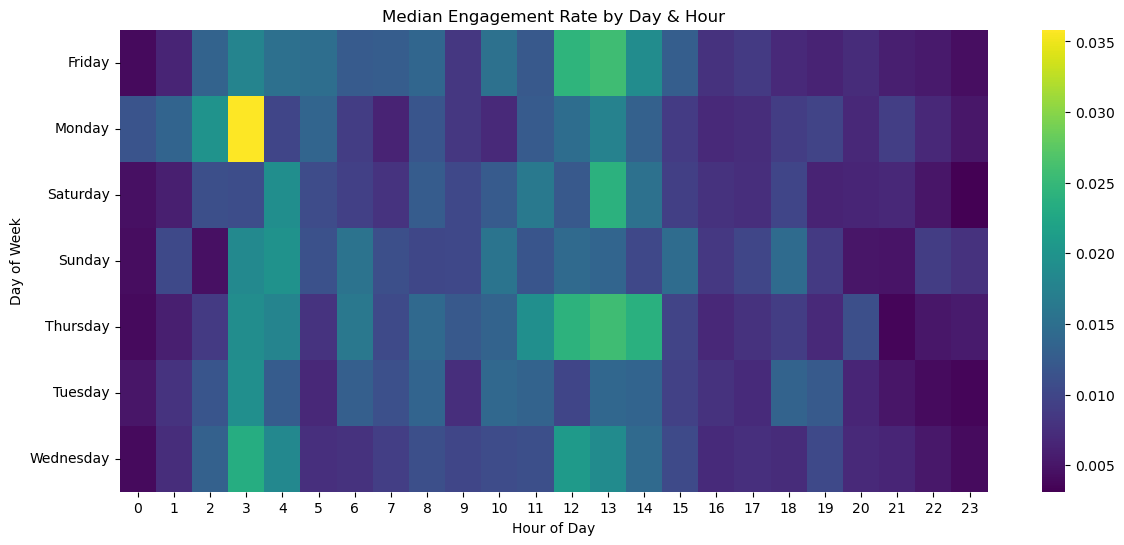

In [101]:
import seaborn as sns
hour_day_engagement = (
    videos_df
    .groupby(['publish_day', 'publish_hour'])['engagement_rate']
    .median()
    .unstack()
)
plt.figure(figsize=(14,6))
sns.heatmap(hour_day_engagement, cmap='viridis')
plt.title('Median Engagement Rate by Day & Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()


This heatmap reveals that typical engagement varies meaningfully across combinations of upload day and hour. Higher median engagement tends to cluster around midday hours on weekdays—especially Thursday and Friday—while late-night and early-morning uploads consistently show lower engagement. The absence of a single dominant hour indicates that optimal posting time is day-dependent rather than universal.

##### Observations from Temporal Analysis

- Engagement levels vary across both upload hours and days, indicating that
  posting time is associated with audience interaction patterns.
- Midday hours generally show higher median engagement compared to late-night
  uploads, suggesting greater audience availability during daytime periods.
- Weekdays—particularly Thursday and Friday—exhibit higher typical engagement
  than weekends.
- The heatmap reveals that optimal posting times depend on the day of the week,
  rather than a single universally best hour.
- While temporal factors influence engagement, the differences are gradual,
  indicating that timing complements content quality rather than replacing it.


### Step 10: Distribution Analysis (Engagement Rate Recap)

This step revisits the distribution of engagement rate to consolidate findings
from earlier analyses. By examining the overall shape of the distribution once
again, we confirm the presence of skewness and the dominance of rare high-
engagement videos before drawing final conclusions.


#####  Overall Engagement Rate Distribution

A histogram is used to visualize how engagement rates are distributed across all
videos. This helps assess whether engagement is evenly spread or concentrated
among a small subset of videos.


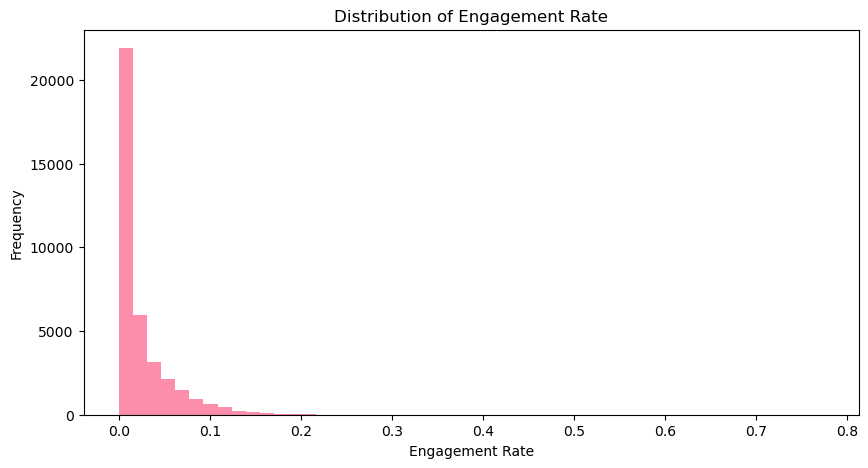

In [106]:
plt.figure(figsize=(10,5))
plt.hist(videos_df['engagement_rate'], bins=50,color="#FC8EAC")
plt.xlabel('Engagement Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Engagement Rate')
plt.show()


The engagement rate distribution is heavily right-skewed, indicating that most
videos receive very low engagement while a small number achieve exceptionally
high interaction. This confirms that viral success is rare and that typical
video performance is dominated by modest audience response.


##### Observations from Distribution Analysis

- Engagement across videos is highly uneven, with a long tail of rare viral
  content.
- The majority of videos cluster near low engagement values, reinforcing that
  high engagement is not the norm.
- This distribution supports earlier findings from univariate and outlier
  analysis, validating the decision to focus on medians and robust statistics.
- The results highlight the importance of analyzing both typical behavior and
  exceptional cases when studying YouTube engagement.


### Step 11:Insight Summary & Interpretation

Exploratory analysis reveals that engagement distribution is highly right-skewed, with most videos receiving low engagement and a small fraction of videos achieving extremely high engagement. This explains why median engagement values remain low despite the presence of high maximum values and confirms the importance of using median-based metrics when evaluating performance.

Analysis of views versus engagement indicates that higher view counts do not necessarily guarantee higher engagement rates, suggesting that audience interaction quality is not solely dependent on reach.

Category-wise analysis shows substantial variation in engagement behavior across content types. While some categories appear more frequently among viral videos, others consistently achieve higher median engagement, indicating differences between viral frequency and typical performance.

Title length analysis suggests that engagement patterns vary across title length groups, with different groups showing varying levels of consistency and occasional extreme outliers. This indicates that title length influences engagement behavior, but does not act as a strict determinant of performance.

Temporal analysis of posting time reveals that engagement varies across both upload hours and days of the week, with certain hour–day combinations consistently demonstrating higher median engagement. Engagement changes across the day follow observable user activity patterns rather than abrupt algorithmic cutoffs.

Overall, viral videos behave as statistical outliers and should be analyzed separately from typical content performance to avoid misleading conclusions.

### Step 12:Actionable Insights & Recommendations

Based on the exploratory analysis, the following recommendations can be derived:

* Since engagement distribution is highly skewed and dominated by outliers, median engagement should be used instead of mean values when evaluating video performance.

* High view counts do not consistently translate into high engagement rates, indicating that content quality and audience relevance are more important than reach alone.

* Certain content categories consistently achieve higher typical engagement, suggesting that category-specific strategies may be more effective than a one-size-fits-all approach.

* Title length influences engagement behavior, but no strict optimal length guarantees success. Different title lengths balance consistency and viral potential differently.

* Posting time affects engagement, with specific hour–day combinations showing higher median engagement. Uploading during these windows may increase the likelihood of better performance.

* Viral videos behave as exceptional cases and should not be treated as representative benchmarks for normal content performance.

### Step 13:Limitations & Future Scope

This analysis is limited to available metadata and does not account for content quality, viewer demographics, or algorithmic promotion factors that may influence engagement. Engagement behavior may also evolve over time, and trends observed in this dataset may not generalize to other regions or time periods.

Future analysis could incorporate predictive modeling to estimate engagement based on multiple features, such as posting time, category, and title characteristics. Separating typical and viral videos into distinct analytical groups may further improve modeling accuracy. Additional features such as sentiment analysis of titles or topic modeling could provide deeper insights into audience engagement drivers.